# Inference Analysis (Split Version): Size and Power of Tests

This notebook analyzes the size (Type I error rate) and power of the split-version inference tests.

Each experiment uses deterministic train/inference splits per seed:
- training split (`n_samples_train`) for model fitting
- inference split (`n_samples_infer`) for Monte Carlo test statistics and p-values

**Objectives**:
1. **Size Analysis**: Calculate the proportion of tests that reject the null hypothesis at the 0.05 significance level when the null is true (should be close to 0.05)
2. **Power Analysis**: Calculate the proportion of tests that reject the null hypothesis when the alternative is true (should increase with effect size)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up display options
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

# Set up plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Define split-version paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'simulations' else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / 'results'
GAMMA_SIZE_FILE = RESULTS_DIR / 'inference_size_gamma_split' / 'inference_size_gamma_split_results_qt.csv'
ETA_SIZE_FILE = RESULTS_DIR / 'inference_size_eta_split' / 'inference_size_eta_split_results_qt.csv'
GAMMA_POWER_FILE = RESULTS_DIR / 'inference_power_gamma_split' / 'inference_power_gamma_combined_results_qt.csv'
ETA_POWER_FILE = RESULTS_DIR / 'inference_power_eta_split' / 'inference_power_eta_combined_results_qt.csv'

print("Setup complete (split version)!")
print(f"Data files:")
print(f"  Gamma Size: {GAMMA_SIZE_FILE}")
print(f"  Eta Size: {ETA_SIZE_FILE}")
print(f"  Gamma Power: {GAMMA_POWER_FILE}")
print(f"  Eta Power: {ETA_POWER_FILE}")


Setup complete (split version)!
Data files:
  Gamma Size: results/inference_size_gamma_split/inference_size_gamma_split_results_qt.csv
  Eta Size: results/inference_size_eta_split/inference_size_eta_split_results_qt.csv
  Gamma Power: results/inference_power_gamma_split/inference_power_gamma_combined_results_qt.csv
  Eta Power: results/inference_power_eta_split/inference_power_eta_combined_results_qt.csv


## 1. Load Split Results Data

Load the split-version results from both size and power experiments.


In [2]:
# Load size data
df_gamma_size = pd.read_csv(GAMMA_SIZE_FILE)
df_eta_size = pd.read_csv(ETA_SIZE_FILE)

# Load power data
df_gamma_power = pd.read_csv(GAMMA_POWER_FILE)
df_eta_power = pd.read_csv(ETA_POWER_FILE)

# Add pattern column to eta power if it doesn't exist (use framework as pattern)
if 'pattern' not in df_eta_power.columns:
    if 'framework' in df_eta_power.columns:
        df_eta_power['pattern'] = df_eta_power['framework']
    else:
        df_eta_power['pattern'] = 'default'

print("Size experiments (split):")
print(f"  Gamma: {df_gamma_size.shape[0]} tests")
print(f"    Train sizes: {sorted(df_gamma_size['n_samples_train'].unique())}")
if 'n_samples_infer' in df_gamma_size.columns:
    print(f"    Infer sizes: {sorted(df_gamma_size['n_samples_infer'].unique())}")
print(f"  Eta: {df_eta_size.shape[0]} tests")
print(f"    Train sizes: {sorted(df_eta_size['n_samples_train'].unique())}")
if 'n_samples_infer' in df_eta_size.columns:
    print(f"    Infer sizes: {sorted(df_eta_size['n_samples_infer'].unique())}")

print("\nPower experiments (split):")
print(f"  Gamma: {df_gamma_power.shape[0]} tests")
print(f"    Gamma values: {sorted(df_gamma_power['gamma'].unique())}")
print(f"    Train sizes: {sorted(df_gamma_power['n_samples_train'].unique())}")
if 'n_samples_infer' in df_gamma_power.columns:
    print(f"    Infer sizes: {sorted(df_gamma_power['n_samples_infer'].unique())}")
print(f"    Patterns: {sorted(df_gamma_power['pattern'].unique())}")
print(f"  Eta: {df_eta_power.shape[0]} tests")
print(f"    Eta values: {sorted(df_eta_power['eta'].unique())}")
print(f"    Train sizes: {sorted(df_eta_power['n_samples_train'].unique())}")
if 'n_samples_infer' in df_eta_power.columns:
    print(f"    Infer sizes: {sorted(df_eta_power['n_samples_infer'].unique())}")
print(f"    Patterns: {sorted(df_eta_power['pattern'].unique())}")


Size experiments (split):
  Gamma: 300 tests
    Train sizes: [np.int64(200), np.int64(500), np.int64(1000)]
    Infer sizes: [np.int64(200), np.int64(300), np.int64(400)]
  Eta: 300 tests
    Train sizes: [np.int64(200), np.int64(500), np.int64(1000)]
    Infer sizes: [np.int64(200), np.int64(300), np.int64(400)]

Power experiments (split):
  Gamma: 1500 tests
    Gamma values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
    Train sizes: [np.int64(200), np.int64(500), np.int64(1000)]
    Infer sizes: [np.int64(200), np.int64(300), np.int64(400)]
    Patterns: ['conditional_chain']
  Eta: 1500 tests
    Eta values: [np.float64(0.5), np.float64(0.7), np.float64(1.0), np.float64(2.0), np.float64(3.0)]
    Train sizes: [np.int64(200), np.int64(500), np.int64(1000)]
    Infer sizes: [np.int64(200), np.int64(300), np.int64(400)]
    Patterns: ['conditional']


## 2. Size Analysis (Type I Error Rate)

For each `(n_samples_train, n_samples_infer)` pair, calculate the proportion of tests with p-value < 0.05.
The size should be close to 0.05 if the test is properly calibrated.


In [3]:
def calculate_size(df, alpha=0.05):
    """
    Calculate size (rejection rate) by split sample-size group.

    Expected columns:
    - n_samples_train
    - n_samples_infer (optional)
    - p_value
    """
    group_cols = ['n_samples_train']
    if 'n_samples_infer' in df.columns:
        group_cols.append('n_samples_infer')

    results = []

    grouped = df.groupby(group_cols, dropna=False)
    for keys, subset in grouped:
        if not isinstance(keys, tuple):
            keys = (keys,)

        n_train = keys[0]
        n_infer = keys[1] if len(keys) > 1 else np.nan

        n_total = len(subset)
        n_rejected = (subset['p_value'] < alpha).sum()
        rejection_rate = n_rejected / n_total if n_total > 0 else np.nan

        if n_total > 0 and np.isfinite(rejection_rate):
            se = np.sqrt(rejection_rate * (1 - rejection_rate) / n_total)
            ci_lower = rejection_rate - 1.96 * se
            ci_upper = rejection_rate + 1.96 * se
        else:
            ci_lower = np.nan
            ci_upper = np.nan

        row = {
            'n_samples_train': n_train,
            'n_tests': n_total,
            'n_rejected': n_rejected,
            'size': rejection_rate,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
        }
        if 'n_samples_infer' in group_cols:
            row['n_samples_infer'] = n_infer

        results.append(row)

    out = pd.DataFrame(results)
    sort_cols = ['n_samples_train']
    if 'n_samples_infer' in out.columns:
        sort_cols.append('n_samples_infer')
    return out.sort_values(sort_cols).reset_index(drop=True)


# Calculate sizes for both experiments
alpha = 0.05
print(f"Calculating rejection rates at nominal significance level α = {alpha}")
print("=" * 70)

size_gamma = calculate_size(df_gamma_size, alpha)
size_eta = calculate_size(df_eta_size, alpha)

print("\nGamma experiment - Size (Rejection Rate):")
print(size_gamma)

print("\n\nEta experiment - Size (Rejection Rate):")
print(size_eta)


Calculating rejection rates at nominal significance level α = 0.05

Gamma experiment - Size (Rejection Rate):
   n_samples_train  n_tests  n_rejected   size  ci_lower  ci_upper  \
0              200      100           4 0.0400    0.0016    0.0784   
1              500      100           7 0.0700    0.0200    0.1200   
2             1000      100           4 0.0400    0.0016    0.0784   

   n_samples_infer  
0              200  
1              300  
2              400  


Eta experiment - Size (Rejection Rate):
   n_samples_train  n_tests  n_rejected   size  ci_lower  ci_upper  \
0              200      100           3 0.0300   -0.0034    0.0634   
1              500      100           5 0.0500    0.0073    0.0927   
2             1000      100           2 0.0200   -0.0074    0.0474   

   n_samples_infer  
0              200  
1              300  
2              400  


### 2.1 Visualize Size

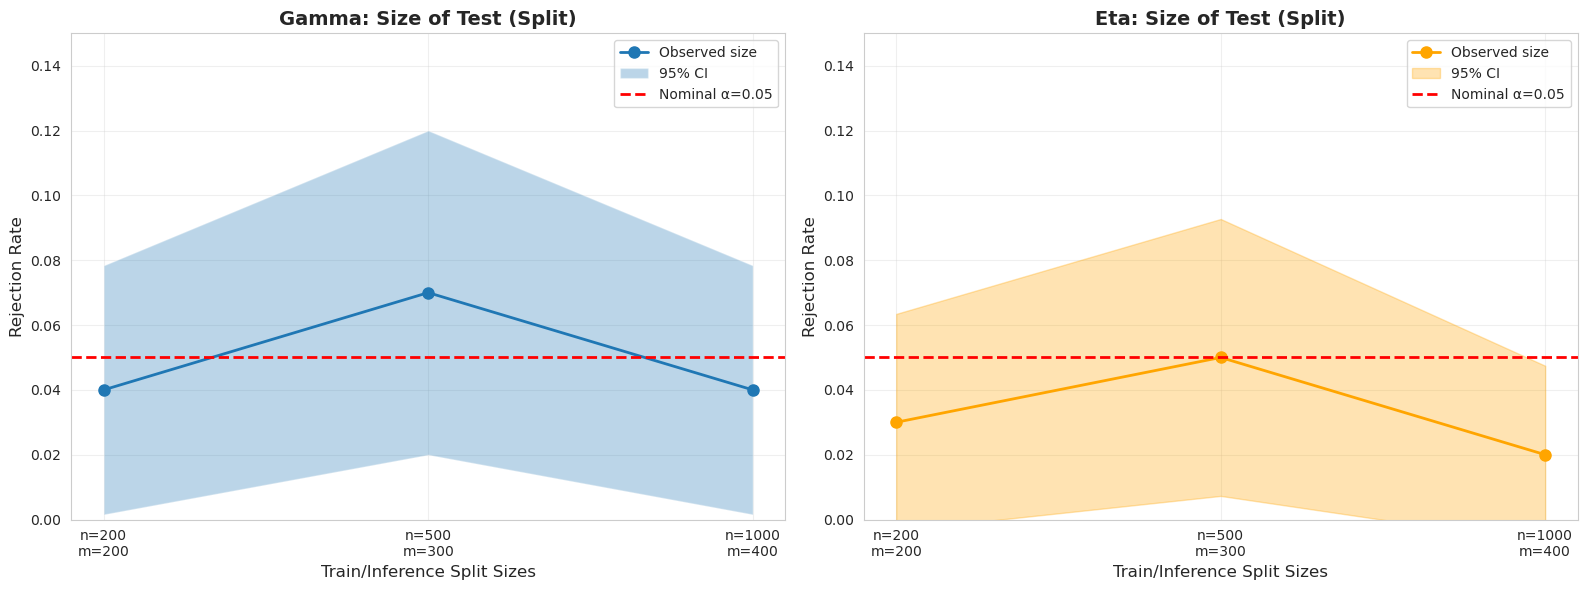


Interpretation:
- The test is well-calibrated if observed size is close to nominal α=0.05
- For split runs, each point corresponds to a (n_train, n_infer) pair


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def make_nm_labels(df):
    if 'n_samples_infer' in df.columns:
        return [f"n={int(n)}\nm={int(m)}" for n, m in zip(df['n_samples_train'], df['n_samples_infer'])]
    return [f"n={int(n)}" for n in df['n_samples_train']]

# Gamma size plot
ax = axes[0]
x_gamma = np.arange(len(size_gamma))
labels_gamma = make_nm_labels(size_gamma)
ax.plot(x_gamma, size_gamma['size'], 'o-', linewidth=2, markersize=8, label='Observed size')
ax.fill_between(x_gamma,
                size_gamma['ci_lower'],
                size_gamma['ci_upper'],
                alpha=0.3, label='95% CI')
ax.axhline(y=alpha, color='r', linestyle='--', linewidth=2, label=f'Nominal α={alpha}')
ax.set_xticks(x_gamma)
ax.set_xticklabels(labels_gamma)
ax.set_xlabel('Train/Inference Split Sizes', fontsize=12)
ax.set_ylabel('Rejection Rate', fontsize=12)
ax.set_title('Gamma: Size of Test (Split)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, max(0.15, size_gamma['ci_upper'].max() * 1.1)])

# Eta size plot
ax = axes[1]
x_eta = np.arange(len(size_eta))
labels_eta = make_nm_labels(size_eta)
ax.plot(x_eta, size_eta['size'], 'o-', linewidth=2, markersize=8, label='Observed size', color='orange')
ax.fill_between(x_eta,
                size_eta['ci_lower'],
                size_eta['ci_upper'],
                alpha=0.3, label='95% CI', color='orange')
ax.axhline(y=alpha, color='r', linestyle='--', linewidth=2, label=f'Nominal α={alpha}')
ax.set_xticks(x_eta)
ax.set_xticklabels(labels_eta)
ax.set_xlabel('Train/Inference Split Sizes', fontsize=12)
ax.set_ylabel('Rejection Rate', fontsize=12)
ax.set_title('Eta: Size of Test (Split)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, max(0.15, size_eta['ci_upper'].max() * 1.1)])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'inference_size_analysis_split.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("- The test is well-calibrated if observed size is close to nominal α=0.05")
print("- For split runs, each point corresponds to a (n_train, n_infer) pair")


## 3. Power Analysis

Analyze power (rejection rate) for different parameter values (gamma and eta) at α = 0.05,
stratified by split sample sizes `(n_samples_train, n_samples_infer)`.
Power should increase as the effect size increases.


In [5]:
def calculate_power(df, param_col, alpha=0.05):
    """
    Calculate power by parameter value, split sample-size group, and pattern.
    """
    results = []

    has_infer = 'n_samples_infer' in df.columns

    if has_infer:
        sample_groups = list(
            df[['n_samples_train', 'n_samples_infer']]
            .drop_duplicates()
            .sort_values(['n_samples_train', 'n_samples_infer'])
            .itertuples(index=False, name=None)
        )
    else:
        sample_groups = [(n, np.nan) for n in sorted(df['n_samples_train'].unique())]

    patterns = sorted(df['pattern'].dropna().unique())

    for param_val in sorted(df[param_col].dropna().unique()):
        for n_train, n_infer in sample_groups:
            for pattern in patterns:
                subset = df[(df[param_col] == param_val) &
                            (df['n_samples_train'] == n_train) &
                            (df['pattern'] == pattern)]
                if has_infer:
                    subset = subset[subset['n_samples_infer'] == n_infer]

                n_total = len(subset)
                n_rejected = (subset['p_value'] < alpha).sum()
                rejection_rate = n_rejected / n_total if n_total > 0 else np.nan

                if n_total > 0 and 0 < rejection_rate < 1:
                    se = np.sqrt(rejection_rate * (1 - rejection_rate) / n_total)
                    ci_lower = rejection_rate - 1.96 * se
                    ci_upper = rejection_rate + 1.96 * se
                else:
                    ci_lower = rejection_rate
                    ci_upper = rejection_rate

                row = {
                    param_col: param_val,
                    'n_samples_train': n_train,
                    'pattern': pattern,
                    'n_tests': n_total,
                    'n_rejected': n_rejected,
                    'power': rejection_rate,
                    'ci_lower': ci_lower,
                    'ci_upper': ci_upper,
                }
                if has_infer:
                    row['n_samples_infer'] = n_infer

                results.append(row)

    out = pd.DataFrame(results)
    sort_cols = [param_col, 'n_samples_train']
    if 'n_samples_infer' in out.columns:
        sort_cols.append('n_samples_infer')
    sort_cols.append('pattern')
    return out.sort_values(sort_cols).reset_index(drop=True)


# Calculate power for both experiments
power_gamma = calculate_power(df_gamma_power, 'gamma', alpha)
power_eta = calculate_power(df_eta_power, 'eta', alpha)

print("Gamma Power Analysis (split):")
print("=" * 70)
gamma_cols = ['n_samples_train', 'pattern']
if 'n_samples_infer' in power_gamma.columns:
    gamma_cols.insert(1, 'n_samples_infer')
gamma_pivot = power_gamma.pivot_table(index='gamma', columns=gamma_cols, values='power')
print(gamma_pivot)

print("\n\nEta Power Analysis (split):")
print("=" * 70)
eta_cols = ['n_samples_train', 'pattern']
if 'n_samples_infer' in power_eta.columns:
    eta_cols.insert(1, 'n_samples_infer')
eta_pivot = power_eta.pivot_table(index='eta', columns=eta_cols, values='power')
print(eta_pivot)

print("\nNote: Values show rejection rate at α=0.05 for each parameter value")


Gamma Power Analysis (split):
n_samples_train              200               500               1000
n_samples_infer               200               300               400
pattern         conditional_chain conditional_chain conditional_chain
gamma                                                                
1.0000                     0.6000            0.9000            0.9300
2.0000                     0.8400            0.9500            1.0000
3.0000                     0.9200            1.0000            1.0000
4.0000                     0.9100            1.0000            1.0000
5.0000                     0.8700            0.9900            1.0000


Eta Power Analysis (split):
n_samples_train        200         500         1000
n_samples_infer         200         300         400
pattern         conditional conditional conditional
eta                                                
0.5000               0.2500      0.4600      0.5800
0.7000               0.5600      0.7700      0.880

### 3.1 Visualize Gamma Power

In [ ]:
patterns = sorted(power_gamma['pattern'].unique())

sample_pairs_df = (
    power_gamma[['n_samples_train', 'n_samples_infer']]
    .drop_duplicates()
    .sort_values(['n_samples_train', 'n_samples_infer'])
)
sample_pairs = list(sample_pairs_df.itertuples(index=False, name=None))

fig, axes = plt.subplots(len(patterns), len(sample_pairs), figsize=(6*len(sample_pairs), 4.5*len(patterns)))

# Ensure axes is 2D
if len(patterns) == 1 and len(sample_pairs) == 1:
    axes = np.array([[axes]])
elif len(patterns) == 1:
    axes = axes.reshape(1, -1)
elif len(sample_pairs) == 1:
    axes = axes.reshape(-1, 1)

for i, pattern in enumerate(patterns):
    for j, (n_train, n_infer) in enumerate(sample_pairs):
        ax = axes[i, j]

        subset = power_gamma[(power_gamma['pattern'] == pattern) &
                             (power_gamma['n_samples_train'] == n_train) &
                             (power_gamma['n_samples_infer'] == n_infer)].sort_values('gamma')

        ax.plot(subset['gamma'], subset['power'], 'o-', linewidth=2, markersize=8)
        ax.fill_between(subset['gamma'], subset['ci_lower'], subset['ci_upper'], alpha=0.3)
        ax.axhline(y=alpha, color='r', linestyle='--', linewidth=2, label=f'α={alpha}')
        ax.set_xlabel('Gamma (γ)', fontsize=11)
        ax.set_ylabel('Power (Rejection Rate)', fontsize=11)
        ax.set_title(f'Pattern: {pattern}, n={int(n_train)}, m={int(n_infer)}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.05])

plt.suptitle('Gamma Power Analysis (Split Version)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'inference_power_gamma_analysis_split.png', dpi=300, bbox_inches='tight')
plt.show()


### 3.2 Visualize Eta Power

In [ ]:
patterns = sorted(power_eta['pattern'].unique())

sample_pairs_df = (
    power_eta[['n_samples_train', 'n_samples_infer']]
    .drop_duplicates()
    .sort_values(['n_samples_train', 'n_samples_infer'])
)
sample_pairs = list(sample_pairs_df.itertuples(index=False, name=None))

fig, axes = plt.subplots(len(patterns), len(sample_pairs), figsize=(6*len(sample_pairs), 4.5*len(patterns)))

# Ensure axes is 2D
if len(patterns) == 1 and len(sample_pairs) == 1:
    axes = np.array([[axes]])
elif len(patterns) == 1:
    axes = axes.reshape(1, -1)
elif len(sample_pairs) == 1:
    axes = axes.reshape(-1, 1)

for i, pattern in enumerate(patterns):
    for j, (n_train, n_infer) in enumerate(sample_pairs):
        ax = axes[i, j]

        subset = power_eta[(power_eta['pattern'] == pattern) &
                           (power_eta['n_samples_train'] == n_train) &
                           (power_eta['n_samples_infer'] == n_infer)].sort_values('eta')

        ax.plot(subset['eta'], subset['power'], 'o-', linewidth=2, markersize=8, color='orange')
        ax.fill_between(subset['eta'], subset['ci_lower'], subset['ci_upper'], alpha=0.3, color='orange')
        ax.axhline(y=alpha, color='r', linestyle='--', linewidth=2, label=f'α={alpha}')
        ax.set_xlabel('Eta (η)', fontsize=11)
        ax.set_ylabel('Power (Rejection Rate)', fontsize=11)
        ax.set_title(f'Pattern: {pattern}, n={int(n_train)}, m={int(n_infer)}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.05])

plt.suptitle('Eta Power Analysis (Split Version)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'inference_power_eta_analysis_split.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Summary Statistics (Split Version)


In [ ]:
print("="*80)
print("SUMMARY (Split Version): Size Analysis")
print("="*80)
print("\nGamma Size:")
print(size_gamma[['n_samples_train', 'n_samples_infer', 'size', 'ci_lower', 'ci_upper']].to_string(index=False))

print("\nEta Size:")
print(size_eta[['n_samples_train', 'n_samples_infer', 'size', 'ci_lower', 'ci_upper']].to_string(index=False))

print("\n" + "="*80)
print("SUMMARY (Split Version): Power Analysis")
print("="*80)
print("\nGamma Power:")
print(gamma_pivot)

print("\nEta Power:")
print(eta_pivot)

# Save summary to CSV (split version)
size_gamma.to_csv(RESULTS_DIR / 'summary_size_gamma_split.csv', index=False)
size_eta.to_csv(RESULTS_DIR / 'summary_size_eta_split.csv', index=False)
power_gamma.to_csv(RESULTS_DIR / 'summary_power_gamma_split.csv', index=False)
power_eta.to_csv(RESULTS_DIR / 'summary_power_eta_split.csv', index=False)

print("\n" + "="*80)
print("Summary files saved:")
print("  - results/summary_size_gamma_split.csv")
print("  - results/summary_size_eta_split.csv")
print("  - results/summary_power_gamma_split.csv")
print("  - results/summary_power_eta_split.csv")
print("="*80)


## 5. Interpretation

### Split-Version Context
- `n_samples_train` controls diffusion model fitting quality.
- `n_samples_infer` controls the stability of inference-side statistics (tau, tau(d), p-values).
- In this setup, `(n_samples_train, n_samples_infer)` pairs are: `(200,200)`, `(500,300)`, `(1000,400)`.

### Size Analysis
- **Goal**: The observed size should be close to the nominal significance level α = 0.05.
- **Interpretation**:
  - If size ≈ 0.05: Test is well-calibrated.
  - If size > 0.05: Test is anti-conservative (too many false positives).
  - If size < 0.05: Test is conservative (too few rejections).

### Power Analysis
- **Goal**: Power should increase as the effect size (gamma or eta) increases.
- **Interpretation**:
  - Higher power = better ability to detect true effects.
  - Power should increase with larger train/inference split sizes.
  - Power should increase with effect size (distance from null hypothesis).
